In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import pool
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data, DataLoader
import torch_geometric.transforms as T

import models

import os
import gzip
from scipy import io
import pickle

AttributeError: partially initialized module 'torch_geometric' has no attribute 'typing' (most likely due to a circular import)

In [2]:
from torch_geometric.explain import Explainer, GNNExplainer, AttentionExplainer, PGExplainer
from torch_geometric.utils import remove_self_loops, to_undirected
from tqdm import tqdm

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
device

device(type='cuda')

# classification model

In [5]:
class Classification(nn.Module):

    def __init__(self, encoder_parameter, pooling_parameter, classifier_parameter):
        super(Classification, self).__init__()
        self.encoder = models.GATEncoder(encoder_parameter[0], encoder_parameter[1], encoder_parameter[2], encoder_parameter[3])
        self.pooling = models.GATPooling(pooling_parameter[0], pooling_parameter[1], pooling_parameter[2])
        self.classifier = models.Classifier(classifier_parameter[0], classifier_parameter[1], classifier_parameter[2])
    
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.encoder(x, edge_index)
        x = self.pooling(x, edge_index, batch)
        x = self.classifier(x)
        return x

class ClassificationSimplifiedPooling(nn.Module):

    def __init__(self, encoder_parameter, classifier_parameter):
        super(ClassificationSimplifiedPooling, self).__init__()
        self.encoder = models.GATEncoder(encoder_parameter[0], encoder_parameter[1], encoder_parameter[2], encoder_parameter[3])
        self.classifier = models.Classifier(classifier_parameter[0], classifier_parameter[1], classifier_parameter[2])
    
    def forward(self, x, edge_index, batch):
        # x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.encoder(x, edge_index)
        
        x1 = pool.global_mean_pool(x, batch)
        x2 = pool.global_max_pool(x, batch)
        
        x = torch.cat([x1, x2], dim=1)
        x = self.classifier(x, edge_index)
        return x

class ClassificationSingleLayerGAT(nn.Module):

    def __init__(self, encoder_parameter, classifier_parameter):
        super(ClassificationSingleLayerGAT, self).__init__()
        self.encoder = models.SingleLayerGATEncoder(encoder_parameter[0], encoder_parameter[1], encoder_parameter[2])
        self.classifier = models.Classifier(classifier_parameter[0], classifier_parameter[1], classifier_parameter[2])
    
    def forward(self, x, edge_index, batch):
        # x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.encoder(x, edge_index)
        
        x1 = pool.global_mean_pool(x, batch)
        x2 = pool.global_max_pool(x, batch)
        
        x = torch.cat([x1, x2], dim=1)
        x = self.classifier(x, edge_index)
        return x

class ClassificationSimplifiedPoolingExplain(nn.Module):

    def __init__(self, encoder_parameter, classifier_parameter):
        super(ClassificationSimplifiedPoolingExplain, self).__init__()
        self.encoder = models.GATEncoder(encoder_parameter[0], encoder_parameter[1], encoder_parameter[2], encoder_parameter[3])
        self.classifier = models.Classifier(classifier_parameter[0], classifier_parameter[1], classifier_parameter[2])

    def forward(self, x, edge_index, batch):
        # x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.encoder(x, edge_index)
        
        x1 = pool.global_mean_pool(x, batch)
        x2 = pool.global_max_pool(x, batch)
        
        x = torch.cat([x1, x2], dim=1)
        x = self.classifier(x, edge_index)
        return F.softmax(x)

# test code

## establish node features and edge index

In [131]:
test_graph = pd.read_pickle(r'..\..\results\graph_classification\xenium\sub_graphs_174c.pkl')

In [5]:
adata = sc.read_h5ad(r"..\..\results\xenium_corrected.h5ad")

NameError: name 'sc' is not defined

In [132]:
with gzip.open(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_174_c\cell_feature_matrix\matrix.mtx.gz', 'rb') as f:
    mtx = io.mmread(f)
features = pd.read_csv(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_174_c\cell_feature_matrix\features.tsv.gz', sep='\t', header=None)
barcodes = pd.read_csv(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_174_c\cell_feature_matrix\barcodes.tsv.gz', sep='\t', header=None)

mtx = mtx.todense().T

In [133]:
mtx = mtx[:,:480]
mtx = pd.DataFrame(mtx, columns=features[1][:480].tolist(), index=barcodes[0].tolist())

In [134]:
mtx

,A2M,ABL1,ABLIM1,ACE2,ACTA2,ACTB,ACTN1,ACTN4,ADAM28,AEBP1,...,UBE2C,VCAN,VEGFA,VSIG4,VSIR,XBP1,XIST,YBX3,ZFHX3,ZNF683
aaabfpmf-1,0,0,1,0,1,1,0,0,0,0,...,0,0,2,0,0,19,1,2,1,0
aaacgbdg-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3,0,0
aaagnejd-1,0,0,0,0,0,4,0,0,0,0,...,0,0,0,0,0,5,0,3,0,0
aaahdald-1,0,0,2,0,1,1,1,1,0,0,...,0,0,0,1,0,10,0,6,0,0
aaaihfjf-1,3,0,2,0,4,6,1,2,0,0,...,0,0,0,0,0,1,1,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oicgklgi-1,0,0,0,0,0,0,1,0,0,0,...,0,0,5,0,0,3,0,1,0,0
oicmffak-1,0,1,0,0,1,4,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0
oicmlgkb-1,0,1,0,0,1,3,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
oidbgokp-1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [39]:
control_elements = features[0][features[0].str.contains('Control')]
print(control_elements)

480      NegControlProbe_00042
481      NegControlProbe_00041
482      NegControlProbe_00039
483      NegControlProbe_00035
484      NegControlProbe_00034
                ...           
536    NegControlCodeword_0536
537    NegControlCodeword_0537
538    NegControlCodeword_0538
539    NegControlCodeword_0539
540    NegControlCodeword_0540
Name: 0, Length: 61, dtype: object


In [19]:
test_graph[0]

[('aaacgbdg-1', 'aabhmlmp-1'),
 ('aaacgbdg-1', 'aabalmko-1'),
 ('aaacgbdg-1', 'aaagnejd-1'),
 ('aaagnejd-1', 'fdjijnpf-1'),
 ('aaagnejd-1', 'aaahdald-1'),
 ('aaagnejd-1', 'aabhmlmp-1'),
 ('aaagnejd-1', 'aaaihfjf-1'),
 ('aaahdald-1', 'aaaihfjf-1'),
 ('aaahdald-1', 'fdipcjam-1'),
 ('aaahdald-1', 'fddmclgn-1'),
 ('aaahdald-1', 'aabhmlmp-1'),
 ('aaaihfjf-1', 'fdipcjam-1'),
 ('aaaihfjf-1', 'fdhohmhc-1'),
 ('aaaihfjf-1', 'aabhmlmp-1'),
 ('aaaihfjf-1', 'fddmclgn-1'),
 ('aabalmko-1', 'aabhmlmp-1'),
 ('aabalmko-1', 'aabifgjb-1'),
 ('aabhmlmp-1', 'fdhohmhc-1'),
 ('aabifgjb-1', 'fdhohmhc-1'),
 ('aabifgjb-1', 'fdipcjam-1'),
 ('adcgjflb-1', 'fddmclgn-1'),
 ('fddmclgn-1', 'fdipcjam-1'),
 ('fddmclgn-1', 'fdhohmhc-1'),
 ('fdhohmhc-1', 'fdipcjam-1')]

In [53]:
nodes = np.unique(test_graph[0])
node_features = mtx.loc[nodes]

In [58]:
def get_index(node):
    return node_features.index.get_loc(node)

edge_index = [(get_index(node1), get_index(node2)) for node1, node2 in test_graph[0]]

In [55]:
node_features

,A2M,ABL1,ABLIM1,ACE2,ACTA2,ACTB,ACTN1,ACTN4,ADAM28,AEBP1,...,UBE2C,VCAN,VEGFA,VSIG4,VSIR,XBP1,XIST,YBX3,ZFHX3,ZNF683
aaacgbdg-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3,0,0
aaagnejd-1,0,0,0,0,0,4,0,0,0,0,...,0,0,0,0,0,5,0,3,0,0
aaahdald-1,0,0,2,0,1,1,1,1,0,0,...,0,0,0,1,0,10,0,6,0,0
aaaihfjf-1,3,0,2,0,4,6,1,2,0,0,...,0,0,0,0,0,1,1,3,0,0
aabalmko-1,0,0,0,0,1,4,2,0,0,0,...,0,0,0,0,1,10,0,4,0,0
aabhmlmp-1,0,1,0,1,1,3,2,1,0,0,...,0,0,0,0,0,10,0,3,0,0
aabifgjb-1,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,3,0,1,0,0
adcgjflb-1,1,0,0,0,2,3,0,2,0,0,...,0,0,4,0,0,7,0,2,0,0
fddmclgn-1,0,1,4,0,0,2,1,1,0,0,...,0,0,0,0,0,10,0,4,0,0
fdhohmhc-1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


## model

In [103]:
test_model = classification([480, [360, 360], 240, [3,3]], [720, 100, 50], [50, [50,20], 2])

In [104]:
test_model.to(device)


classification(
  (encoder): GATEncoder(
    (conv1): GATConv(480, 360, heads=3)
    (convs): ModuleList(
      (0): GATConv(1080, 360, heads=3)
    )
    (conv_out): GATConv(1080, 240, heads=3)
  )
  (pooling): GATPooling(
    (encoder1): GCNConv(720, 100)
    (pool1): SAGPooling(GraphConv, 100, ratio=0.5, multiplier=1.0)
    (encoder2): GCNConv(100, 50)
    (pool2): SAGPooling(GraphConv, 50, ratio=0.5, multiplier=1.0)
  )
  (classifier): Classifier(
    (fc1): Linear(in_features=50, out_features=50, bias=True)
    (fcs): ModuleList(
      (0): Linear(in_features=50, out_features=20, bias=True)
    )
    (out): Linear(in_features=20, out_features=2, bias=True)
    (softmax): Softmax(dim=1)
  )
)

In [105]:
data = Data(x=torch.tensor(node_features.values, dtype=torch.float32), edge_index=torch.tensor(edge_index, dtype=torch.long).t().contiguous(), batch=torch.tensor([0]*len(node_features)))

In [106]:
data.to(device)

Data(x=[12, 480], edge_index=[2, 24], batch=[12])

## check model output

In [107]:
test_model(data)

tensor([[0.5364, 0.4636]], device='cuda:0', grad_fn=<SoftmaxBackward0>)

In [108]:
z = test_model.encoder(data.x, data.edge_index)
z = test_model.pooling(z, data.edge_index, data.batch)

In [110]:
z.shape

torch.Size([1, 50])

# Load data

In [6]:
from joblib import Parallel, delayed

In [7]:
def dataObject(graph, exp_df, ssa):
    nodes = np.unique(graph)
    node_features = exp_df.loc[nodes]
    # print(node_features.shape)
    edge_index = [(node_features.index.get_loc(node1), node_features.index.get_loc(node2)) for node1, node2 in graph]
    data = Data(x=torch.tensor(node_features.values, dtype=torch.float32), edge_index=torch.tensor(edge_index, dtype=torch.long).t().contiguous(), label=torch.tensor([ssa]))
    return data

In [8]:
marker_orders =['RO60', 'RO52', 'COL1', 'KRT14', 'KRT7', 'KRT5', 'AQP5', 'CD20', 'CD4', 'CD21', 'CD8', 'CD68', 'KI67']

## 126-1

In [9]:
graph = pd.read_pickle(r'..\..\results\gat\sub_graphs_1261.pkl')
graph = [item for item in graph if len(item) > 0]

# with gzip.open(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\matrix.mtx.gz', 'rb') as f:
#     mtx = io.mmread(f)
# features = pd.read_csv(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\features.tsv.gz', sep='\t', header=None)
# barcodes = pd.read_csv(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\barcodes.tsv.gz', sep='\t', header=None)

# mtx = mtx.todense().T
# exp_df = pd.DataFrame(mtx[:,:480], columns=features[1].tolist()[:480], index=barcodes[0].tolist())
exp_df = pd.read_csv(r'..\..\results\gat\126-1_spatial_filtered.csv')
label = exp_df['label'].tolist()
exp_df = exp_df.drop(columns=['label', 'area', 'row', 'col'])

exp_df = (exp_df - exp_df.mean(axis=0)) / exp_df.std(axis=0)

exp_df.index = label

# order columns by marker_orders
exp_df = exp_df[marker_orders]
# exp_df.drop(columns=['sample'], inplace=True)

In [10]:
data_1261 = Parallel(n_jobs=8, verbose=100)(delayed(dataObject)(graph[i], exp_df, 0) for i in range(len(graph)))

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   1 tasks      | elapsed:   12.9s
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:   12.9s
[Parallel(n_jobs=8)]: Done   3 tasks      | elapsed:   12.9s
[Parallel(n_jobs=8)]: Done   4 tasks      | elapsed:   13.0s
[Parallel(n_jobs=8)]: Done   5 tasks      | elapsed:   13.0s
[Parallel(n_jobs=8)]: Done   6 tasks      | elapsed:   13.0s
[Parallel(n_jobs=8)]: Done   7 tasks      | elapsed:   13.0s
[Parallel(n_jobs=8)]: Done   8 tasks      | elapsed:   13.0s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:   13.0s
[Parallel(n_jobs=8)]: Done  10 tasks      | elapsed:   13.0s
[Parallel(n_jobs=8)]: Done  11 tasks      | elapsed:   13.1s
[Parallel(n_jobs=8)]: Done  12 tasks      | elapsed:   13.1s
[Parallel(n_jobs=8)]: Done  13 tasks      | elapsed:   13.1s
[Parallel(n_jobs=8)]: Done  14 tasks      | elapsed:   13.1s
[Parallel(n_jobs=8)]: Done  15 tasks      | elapsed:   13.1s
[Parallel(

In [11]:
with open(r'..\..\results\gat\torch_geometric_data\sub_graphs_1261.pkl', 'wb') as f:
    pickle.dump(data_1261, f)

## 1262

In [12]:
graph = pd.read_pickle(r'..\..\results\gat\sub_graphs_1262.pkl')
graph = [item for item in graph if len(item) > 0]

# with gzip.open(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\matrix.mtx.gz', 'rb') as f:
#     mtx = io.mmread(f)
# features = pd.read_csv(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\features.tsv.gz', sep='\t', header=None)
# barcodes = pd.read_csv(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\barcodes.tsv.gz', sep='\t', header=None)

# mtx = mtx.todense().T
# exp_df = pd.DataFrame(mtx[:,:480], columns=features[1].tolist()[:480], index=barcodes[0].tolist())
exp_df = pd.read_csv(r'..\..\results\gat\126-2_spatial_filtered.csv')
label = exp_df['label'].tolist()
exp_df = exp_df.drop(columns=['label', 'area', 'row', 'col'])

exp_df = (exp_df - exp_df.mean(axis=0)) / exp_df.std(axis=0)

exp_df.index = label
exp_df = exp_df[marker_orders]
# exp_df.drop(columns=['sample'], inplace=True)

In [13]:
data_1262 = Parallel(n_jobs=8, verbose=100)(delayed(dataObject)(graph[i], exp_df, 0) for i in range(len(graph)))

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Batch computation too fast (0.014513254165649414s.) Setting batch_size=2.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  13 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  14 tasks

In [14]:
with open(r'..\..\results\gat\torch_geometric_data\sub_graphs_1262.pkl', 'wb') as f:
    pickle.dump(data_1262, f)

## 72231

In [15]:
graph = pd.read_pickle(r'..\..\results\gat\sub_graphs_72231.pkl')
graph = [item for item in graph if len(item) > 0]

# with gzip.open(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\matrix.mtx.gz', 'rb') as f:
#     mtx = io.mmread(f)
# features = pd.read_csv(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\features.tsv.gz', sep='\t', header=None)
# barcodes = pd.read_csv(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\barcodes.tsv.gz', sep='\t', header=None)

# mtx = mtx.todense().T
# exp_df = pd.DataFrame(mtx[:,:480], columns=features[1].tolist()[:480], index=barcodes[0].tolist())
exp_df = pd.read_csv(r'..\..\results\gat\7223-1_spatial_filtered.csv')
label = exp_df['label'].tolist()
exp_df = exp_df.drop(columns=['label', 'area', 'row', 'col'])

exp_df = (exp_df - exp_df.mean(axis=0)) / exp_df.std(axis=0)

exp_df.index = label
exp_df = exp_df[marker_orders]
# exp_df.drop(columns=['sample'], inplace=True)

In [16]:
data_72231 = Parallel(n_jobs=8, verbose=100)(delayed(dataObject)(graph[i], exp_df, 0) for i in range(len(graph)))

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Batch computation too fast (0.016005277633666992s.) Setting batch_size=2.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  13 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  14 tasks

In [17]:
with open(r'..\..\results\gat\torch_geometric_data\sub_graphs_72231.pkl', 'wb') as f:
    pickle.dump(data_72231, f)

## 72232

In [18]:
graph = pd.read_pickle(r'..\..\results\gat\sub_graphs_72232.pkl')
graph = [item for item in graph if len(item) > 0]

# with gzip.open(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\matrix.mtx.gz', 'rb') as f:
#     mtx = io.mmread(f)
# features = pd.read_csv(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\features.tsv.gz', sep='\t', header=None)
# barcodes = pd.read_csv(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\barcodes.tsv.gz', sep='\t', header=None)

# mtx = mtx.todense().T
# exp_df = pd.DataFrame(mtx[:,:480], columns=features[1].tolist()[:480], index=barcodes[0].tolist())
exp_df = pd.read_csv(r'..\..\results\gat\7223-2_spatial_filtered.csv')
label = exp_df['label'].tolist()
exp_df = exp_df.drop(columns=['label', 'area', 'row', 'col'])

exp_df = (exp_df - exp_df.mean(axis=0)) / exp_df.std(axis=0)

exp_df.index = label
exp_df = exp_df[marker_orders]
# exp_df.drop(columns=['sample'], inplace=True)

In [19]:
data_72232 = Parallel(n_jobs=8, verbose=100)(delayed(dataObject)(graph[i], exp_df, 0) for i in range(len(graph)))

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Batch computation too fast (0.016003847122192383s.) Setting batch_size=2.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  13 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  14 tasks

In [20]:
with open(r'..\..\results\gat\torch_geometric_data\sub_graphs_72232.pkl', 'wb') as f:
    pickle.dump(data_72232, f)

## 83

In [21]:
graph = pd.read_pickle(r'..\..\results\gat\sub_graphs_83.pkl')
graph = [item for item in graph if len(item) > 0]

# with gzip.open(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\matrix.mtx.gz', 'rb') as f:
#     mtx = io.mmread(f)
# features = pd.read_csv(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\features.tsv.gz', sep='\t', header=None)
# barcodes = pd.read_csv(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\barcodes.tsv.gz', sep='\t', header=None)

# mtx = mtx.todense().T
# exp_df = pd.DataFrame(mtx[:,:480], columns=features[1].tolist()[:480], index=barcodes[0].tolist())
exp_df = pd.read_csv(r'..\..\results\gat\83_spatial_filtered.csv')
label = exp_df['label'].tolist()
exp_df = exp_df.drop(columns=['label', 'area', 'row', 'col'])

exp_df = (exp_df - exp_df.mean(axis=0)) / exp_df.std(axis=0)

exp_df.index = label
exp_df = exp_df[marker_orders]
# exp_df.drop(columns=['sample'], inplace=True)

In [22]:
data_83 = Parallel(n_jobs=8, verbose=100)(delayed(dataObject)(graph[i], exp_df, 1) for i in range(len(graph)))

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Batch computation too fast (0.022518396377563477s.) Setting batch_size=2.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  13 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  14 tasks

In [23]:
with open(r'..\..\results\gat\torch_geometric_data\sub_graphs_83.pkl', 'wb') as f:
    pickle.dump(data_83, f)

## 134

In [24]:
graph = pd.read_pickle(r'..\..\results\gat\sub_graphs_134.pkl')
graph = [item for item in graph if len(item) > 0]

# with gzip.open(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\matrix.mtx.gz', 'rb') as f:
#     mtx = io.mmread(f)
# features = pd.read_csv(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\features.tsv.gz', sep='\t', header=None)
# barcodes = pd.read_csv(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\barcodes.tsv.gz', sep='\t', header=None)

# mtx = mtx.todense().T
# exp_df = pd.DataFrame(mtx[:,:480], columns=features[1].tolist()[:480], index=barcodes[0].tolist())
exp_df = pd.read_csv(r'..\..\results\gat\134_spatial_filtered.csv')
label = exp_df['label'].tolist()
exp_df = exp_df.drop(columns=['label', 'area', 'row', 'col'])

exp_df = (exp_df - exp_df.mean(axis=0)) / exp_df.std(axis=0)

exp_df.index = label
exp_df = exp_df[marker_orders]
# exp_df.drop(columns=['sample'], inplace=True)

In [25]:
data_134 = Parallel(n_jobs=8, verbose=100)(delayed(dataObject)(graph[i], exp_df, 1) for i in range(len(graph)))

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Batch computation too fast (0.017038345336914062s.) Setting batch_size=2.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  13 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  14 tasks

In [26]:
with open(r'..\..\results\gat\torch_geometric_data\sub_graphs_134.pkl', 'wb') as f:
    pickle.dump(data_134, f)

## 141

In [27]:
graph = pd.read_pickle(r'..\..\results\gat\sub_graphs_141.pkl')
graph = [item for item in graph if len(item) > 0]

# with gzip.open(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\matrix.mtx.gz', 'rb') as f:
#     mtx = io.mmread(f)
# features = pd.read_csv(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\features.tsv.gz', sep='\t', header=None)
# barcodes = pd.read_csv(r'..\..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\barcodes.tsv.gz', sep='\t', header=None)

# mtx = mtx.todense().T
# exp_df = pd.DataFrame(mtx[:,:480], columns=features[1].tolist()[:480], index=barcodes[0].tolist())
exp_df = pd.read_csv(r'..\..\results\gat\141_spatial_filtered.csv')
label = exp_df['label'].tolist()
exp_df = exp_df.drop(columns=['label', 'area', 'row', 'col'])

exp_df = (exp_df - exp_df.mean(axis=0)) / exp_df.std(axis=0)

exp_df.index = label
exp_df = exp_df[marker_orders]
# exp_df.drop(columns=['sample'], inplace=True)

In [28]:
data_141 = Parallel(n_jobs=8, verbose=100)(delayed(dataObject)(graph[i], exp_df, 1) for i in range(len(graph)))

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Batch computation too fast (0.014521598815917969s.) Setting batch_size=2.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  13 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  14 tasks

In [29]:
with open(r'..\..\results\gat\torch_geometric_data\sub_graphs_141.pkl', 'wb') as f:
    pickle.dump(data_141, f)

## load saved data

In [9]:
data_1261 = pd.read_pickle(r'..\..\results\gat\torch_geometric_data\sub_graphs_1261.pkl')
data_1262 = pd.read_pickle(r'..\..\results\gat\torch_geometric_data\sub_graphs_1262.pkl')
data_72231 = pd.read_pickle(r'..\..\results\gat\torch_geometric_data\sub_graphs_72231.pkl')
data_72232 = pd.read_pickle(r'..\..\results\gat\torch_geometric_data\sub_graphs_72232.pkl')
data_83 = pd.read_pickle(r'..\..\results\gat\torch_geometric_data\sub_graphs_83.pkl')
data_134 = pd.read_pickle(r'..\..\results\gat\torch_geometric_data\sub_graphs_134.pkl')
data_141 = pd.read_pickle(r'..\..\results\gat\torch_geometric_data\sub_graphs_141.pkl')

# training

## train/test split

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
data = data_83 + data_134 + data_141 + data_1261 + data_1262 + data_72231 + data_72232
labels = ['SSA+']*(len(data_83)+len(data_134)+len(data_141)) + ['SSA-']*(len(data_1261)+len(data_1262)+len(data_72231)+len(data_72232))

In [12]:
train_data, test_data, train_label, test_label = train_test_split(data, labels, test_size=0.2, random_state=42)
train_data, val_data, train_label, val_label = train_test_split(train_data, train_label, test_size=0.25, random_state=42)

In [13]:
len(train_data)

6174

In [14]:
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
val_loader = DataLoader(val_data, batch_size=256, shuffle=False)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

c:\Users\zfang38\AppData\Local\anaconda3\envs\torchEnv\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


## train and evaluate the model

In [43]:
from torch.nn import CrossEntropyLoss
from torch.optim import Adam, SGD

In [44]:
# model = Classification([480, [360], 240, [3]], [720, 100, 50], [50, [20], 2])
model = ClassificationSingleLayerGAT([13, 4, 1], [8, [4], 2])

In [45]:
model.to(device)

ClassificationSingleLayerGAT(
  (encoder): SingleLayerGATEncoder(
    (conv): GATConv(13, 4, heads=1)
  )
  (classifier): Classifier(
    (fc1): Linear(in_features=8, out_features=4, bias=True)
    (fcs): ModuleList()
    (out): Linear(in_features=4, out_features=2, bias=True)
  )
)

In [46]:
n_ssa_pos = np.sum(np.array(train_label) == 'SSA+')
n_ssa_neg = np.sum(np.array(train_label) == 'SSA-')
labels_weights = torch.tensor([1.0 / n_ssa_neg, 1.0 / n_ssa_pos], dtype=torch.float32)
labels_weights = labels_weights / labels_weights.sum()

In [47]:
optimizer = SGD(model.parameters(), lr=0.01)
criterion = CrossEntropyLoss(labels_weights.to(device))

In [48]:
def train(loader):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        if data.label.shape[0] != out.shape[0]:
            min_size = min(out.shape[0], data.label.shape[0])
            out = out[:min_size]
            data.label = data.label[:min_size]
        loss = criterion(out, data.label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

def val(loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)

            # Ensure label shape matches output
            if data.label.shape[0] != out.shape[0]:
                min_size = min(out.shape[0], data.label.shape[0])
                out = out[:min_size]
                data.label = data.label[:min_size]

            loss = criterion(out, data.label)
            total_loss += loss.item() * data.num_graphs

    return total_loss / len(loader.dataset)


In [49]:
epochs = 1000

In [50]:
train_losses = []
val_losses = []
test_losses = []

for epoch in range(epochs):
    train_loss = train(train_loader)
    val_loss = val(val_loader)
    test_loss = val(test_loader)
    print(f'Epoch: {epoch}, Train Loss: {train_loss}, Val Loss: {val_loss}, Test Loss: {test_loss}')
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    test_losses.append(test_loss)

Epoch: 0, Train Loss: 0.7360657005391925, Val Loss: 0.7217250460557072, Test Loss: 0.7157742295698265
Epoch: 1, Train Loss: 0.7207792274844581, Val Loss: 0.7087375882645728, Test Loss: 0.705754803071154
Epoch: 2, Train Loss: 0.7120916461303546, Val Loss: 0.7019528823028554, Test Loss: 0.700804234101044
Epoch: 3, Train Loss: 0.7073407379562198, Val Loss: 0.6983377397957793, Test Loss: 0.6981923941155554
Epoch: 4, Train Loss: 0.7044003908789425, Val Loss: 0.6960226180716705, Test Loss: 0.6964974414381719
Epoch: 5, Train Loss: 0.7026795051342699, Val Loss: 0.6941017605194251, Test Loss: 0.695126658709898
Epoch: 6, Train Loss: 0.7007373318843637, Val Loss: 0.6931384264583319, Test Loss: 0.694286417937962
Epoch: 7, Train Loss: 0.6995775550362513, Val Loss: 0.6921798477710133, Test Loss: 0.6935865978930632
Epoch: 8, Train Loss: 0.6984538348855654, Val Loss: 0.6914097082562791, Test Loss: 0.6929721762509876
Epoch: 9, Train Loss: 0.6975790818300609, Val Loss: 0.6907617914381393, Test Loss: 0.6

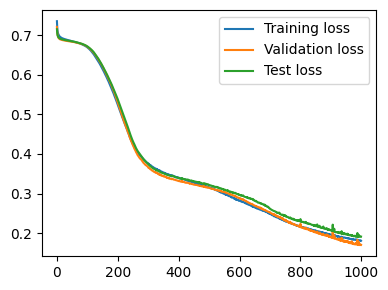

In [51]:
fig, ax = plt.subplots(1,1, figsize=(4,3))
ax.plot(train_losses, label='Training loss')
ax.plot(val_losses, label='Validation loss')
ax.plot(test_losses, label='Test loss')
ax.legend()
plt.tight_layout()
plt.savefig(r'..\..\figures\gat\if_loss.png')

In [52]:
# Pooling of all graphs and save pooled features for downstream analysis
model.eval()
pooled_features = []

data = data_83 + data_134 + data_141 + data_1261 + data_1262 + data_72231 + data_72232
data_loader = DataLoader(data, batch_size=256, shuffle=False)

with torch.no_grad():
    for data in data_loader:
        data = data.to(device)
        out = model.encoder(data.x, data.edge_index)
        # out = model.pooling(out, data.edge_index, data.batch)
        out1 = pool.global_mean_pool(out, data.batch)
        out2 = pool.global_max_pool(out, data.batch)
        out = torch.cat([out1, out2], dim=1)

        pooled_features.append(out.cpu().numpy())

c:\Users\zfang38\AppData\Local\anaconda3\envs\torchEnv\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [53]:
pooled_features[0].shape

(256, 8)

In [54]:
with open(r'..\..\results\gat\pooled_features_normalized_data.pkl', 'wb') as f:
    pickle.dump(pooled_features, f)

In [55]:
with open(r'..\..\results\gat\pooled_labels_normalized_data.pkl', 'wb') as f:
    pickle.dump(['SSA+']*(len(data_83)+len(data_134)+len(data_141)) + ['SSA-']*(len(data_1261)+len(data_1262)+len(data_72231)+len(data_72232)), f)

In [56]:
# save model
torch.save(model, r'..\..\results\gat\model_normalized_data.pth')

In [57]:
tissue_id = ['83']*len(data_83) + ['134']*len(data_134) + ['141']*len(data_141) + ['126-1']*len(data_1261) + ['126-2']*len(data_1262) + ['7223-1']*len(data_72231) + ['7223-2']*len(data_72232)
with open(r'..\..\results\gat\tissue_id.pkl', 'wb') as f:
    pickle.dump(tissue_id, f)

In [58]:
# torch.save(model.state_dict(), r'..\..\results\graph_classification\xenium\model_state_dict_normalized_data.pt')

# Raw classification logit

In [59]:
model = torch.load(r'..\..\results\gat\model_normalized_data.pth', weights_only=False)

In [60]:
# Pooling of all graphs and save pooled features for downstream analysis
model.eval()
pooled_logit = []

data = data_83 + data_134 + data_141 + data_1261 + data_1262 + data_72231 + data_72232
data_loader = DataLoader(data, batch_size=128, shuffle=False)

with torch.no_grad():
    for data in data_loader:
        data = data.to(device)
        out = model.forward(data.x, data.edge_index, data.batch)
        pooled_logit.append(out.cpu().numpy())

In [61]:
with open(r'..\..\results\gat\logit_normalized_data.pkl', 'wb') as f:
    pickle.dump(pooled_logit, f)

# Explainability

In [16]:
# explain_model = ClassificationSimplifiedPoolingExplain([480, [360], 240, [3]], [1440, [500, 100], 2])

model = torch.load(r'..\..\results\graph_classification\xenium\model_normalized_data.pth', weights_only=False)

# explain_model.load_state_dict(model.state_dict())

In [17]:
# explain_model.eval()
# with torch.no_grad():
#     data = data_83a[0]
#     print(explain_model(data.x, data.edge_index, data.batch))

In [18]:
# model.to('cpu')

In [19]:
# explain_model.to(device)
model.to(device)

ClassificationSimplifiedPooling(
  (encoder): GATEncoder(
    (conv1): GATConv(480, 360, heads=3)
    (convs): ModuleList()
    (conv_out): GATConv(1080, 240, heads=3)
  )
  (classifier): Classifier(
    (fc1): Linear(in_features=1440, out_features=500, bias=True)
    (fcs): ModuleList(
      (0): Linear(in_features=500, out_features=100, bias=True)
    )
    (out): Linear(in_features=100, out_features=2, bias=True)
  )
)

## gnn explainer

### phenomenon explainer

In [30]:
explainer = Explainer(model,
                      algorithm=GNNExplainer(),
                      explanation_type='phenomenon',
                      node_mask_type='attributes',
                      edge_mask_type='object',
                      model_config=dict(mode='multiclass_classification',
                                        task_level='graph',
                                        return_type='raw')
                    )

In [31]:
data.label.shape

torch.Size([256])

In [32]:
with torch.no_grad():
    output = model(data.x, data.edge_index, data.batch)

In [33]:
data.label.dtype

torch.int64

In [34]:
data_og = data_83a + data_83b + data_84a + data_84b + data_174c + data_174d + data_7202c + data_7202d
data_loader = DataLoader(data_og, batch_size=256, shuffle=False)

explainations = []
for data in data_loader:
    data = data.to(device)
    explanation = explainer(data.x, data.edge_index, batch = data.batch, target=data.label)
    explainations.append(explanation)

c:\Users\zfang38\Anaconda3\envs\torchEnv3\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
c:\Users\zfang38\Anaconda3\envs\torchEnv3\lib\site-packages\torch_geometric\warnings.py:11: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)


In [35]:
explanation = explainations[0]
node_masks = explanation.node_mask.cpu().numpy()
edge_masks = explanation.edge_mask.cpu().numpy()
edge_index = explanation.edge_index.cpu().numpy()
batches = np.unique(explanation.batch.cpu().numpy())
batch_label = explanation.batch.cpu().numpy()

In [36]:
mask = batch_label == 0
n_nodes = int(np.sum(mask))

In [37]:
# find edges connecting nodes with index 0-8, and remove the edge from the edge_index
edges = []
for edge in edge_index.T:
    if edge[0] < n_nodes and edge[1] < n_nodes:
        edges.append(edge)
edges = np.array(edges)
edges = np.unique(edges, axis=0)

In [38]:
edges.shape

(18, 2)

In [39]:
temp = edge_masks[:edges.shape[0]]
edge_masks = edge_masks[edges.shape[0]:]

In [40]:
node_masks[mask].shape

(9, 480)

In [41]:
data_83a[0]

Data(x=[9, 480], edge_index=[2, 18], label=[1])

In [42]:
edge_masks = []
node_masks = []
for explanation in explainations:
    edge_masks.append(explanation.edge_mask.cpu().numpy())
    node_masks.append(explanation.node_mask.cpu().numpy())
edge_masks = np.concatenate(edge_masks, axis=0)
node_masks = np.concatenate(node_masks, axis=0)

In [43]:
node_masks.shape

(736800, 480)

In [44]:
graph_explanations = []
curr_node_idx = 0
curr_edge_idx = 0
for i, data in enumerate(data_og):
    if data.x.shape[0] == 0:
        graph_explanations.append((np.array([]), np.array([])))
        continue
    node_mask = node_masks[curr_node_idx:curr_node_idx+data.x.shape[0]]
    edge_mask = edge_masks[curr_edge_idx:curr_edge_idx+data.edge_index.shape[1]]
    graph_explanations.append((node_mask, edge_mask))
    curr_node_idx += data.x.shape[0]
    curr_edge_idx += data.edge_index.shape[1]

In [45]:
# graph_explanations =[]
# for i, explanation in tqdm(enumerate(explainations)):
#     batches = np.unique(explanation.batch.cpu().numpy())
#     batch_label = explanation.batch.cpu().numpy()
#     edge_index = explanation.edge_index.cpu().numpy()
#     edge_masks = explanation.edge_mask.cpu().numpy()
#     node_masks = explanation.node_mask.cpu().numpy()
#     for batch in batches:
#         mask = batch_label == batch
#         n_nodes = int(np.sum(mask))
#         edges = []
#         for edge in edge_index.T:
#             if edge[0] < n_nodes and edge[1] < n_nodes and edge[0] >= 0 and edge[1] >= 0:
#                 edges.append(edge)
#         edges = np.array(edges)
#         edge_index = edge_index - n_nodes
#         graph_explanations.append((node_masks[mask], edge_masks[:edges.shape[0]], edges))
#         edge_masks = edge_masks[edges.shape[0]:]

In [46]:
# with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data.pkl', 'wb') as f:
#     pickle.dump(graph_explanations, f)

In [47]:
graph_explanations_83a = graph_explanations[:len(data_83a)]
graph_explanations_83b = graph_explanations[len(data_83a):len(data_83a)+len(data_83b)]
graph_explanations_84a = graph_explanations[len(data_83a)+len(data_83b):len(data_83a)+len(data_83b)+len(data_84a)]
graph_explanations_84b = graph_explanations[len(data_83a)+len(data_83b)+len(data_84a):len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)]
graph_explanations_174c = graph_explanations[len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b):len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)+len(data_174c)]
graph_explanations_174d = graph_explanations[len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)+len(data_174c):len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)+len(data_174c)+len(data_174d)]
graph_explanations_7202c = graph_explanations[len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)+len(data_174c)+len(data_174d):len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)+len(data_174c)+len(data_174d)+len(data_7202c)]
graph_explanations_7202d = graph_explanations[len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)+len(data_174c)+len(data_174d)+len(data_7202c):]

In [48]:
with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_phenomenon_83a.pkl', 'wb') as f:
    pickle.dump(graph_explanations_83a, f)

with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_phenomenon_83b.pkl', 'wb') as f:
    pickle.dump(graph_explanations_83b, f)

with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_phenomenon_84a.pkl', 'wb') as f:
    pickle.dump(graph_explanations_84a, f)

with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_phenomenon_84b.pkl', 'wb') as f:
    pickle.dump(graph_explanations_84b, f)

with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_phenomenon_174c.pkl', 'wb') as f:
    pickle.dump(graph_explanations_174c, f)

with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_phenomenon_174d.pkl', 'wb') as f:
    pickle.dump(graph_explanations_174d, f)

with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_phenomenon_7202c.pkl', 'wb') as f:
    pickle.dump(graph_explanations_7202c, f)

with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_phenomenon_7202d.pkl', 'wb') as f:
    pickle.dump(graph_explanations_7202d, f)

### model explanation

In [18]:
explainer = Explainer(model,
                      algorithm=GNNExplainer(),
                      explanation_type='model',
                      node_mask_type='attributes',
                      edge_mask_type='object',
                      model_config=dict(mode='multiclass_classification',
                                        task_level='graph',
                                        return_type='raw')
                    )

In [19]:
data_og = data_83a + data_83b + data_84a + data_84b + data_174c + data_174d + data_7202c + data_7202d
data_loader = DataLoader(data_og, batch_size=256, shuffle=False)

explainations = []
for data in data_loader:
    data = data.to(device)
    explanation = explainer(data.x, data.edge_index, batch = data.batch)
    explainations.append(explanation)

c:\Users\zfang38\Anaconda3\envs\torchEnv3\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
c:\Users\zfang38\Anaconda3\envs\torchEnv3\lib\site-packages\torch_geometric\warnings.py:11: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)


In [20]:
edge_masks = []
node_masks = []
for explanation in explainations:
    edge_masks.append(explanation.edge_mask.cpu().numpy())
    node_masks.append(explanation.node_mask.cpu().numpy())
edge_masks = np.concatenate(edge_masks, axis=0)
node_masks = np.concatenate(node_masks, axis=0)

In [21]:
graph_explanations = []
curr_node_idx = 0
curr_edge_idx = 0
for i, data in enumerate(data_og):
    if data.x.shape[0] == 0:
        graph_explanations.append((np.array([]), np.array([])))
        continue
    node_mask = node_masks[curr_node_idx:curr_node_idx+data.x.shape[0]]
    edge_mask = edge_masks[curr_edge_idx:curr_edge_idx+data.edge_index.shape[1]]
    graph_explanations.append((node_mask, edge_mask))
    curr_node_idx += data.x.shape[0]
    curr_edge_idx += data.edge_index.shape[1]

In [22]:
graph_explanations_83a = graph_explanations[:len(data_83a)]
graph_explanations_83b = graph_explanations[len(data_83a):len(data_83a)+len(data_83b)]
graph_explanations_84a = graph_explanations[len(data_83a)+len(data_83b):len(data_83a)+len(data_83b)+len(data_84a)]
graph_explanations_84b = graph_explanations[len(data_83a)+len(data_83b)+len(data_84a):len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)]
graph_explanations_174c = graph_explanations[len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b):len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)+len(data_174c)]
graph_explanations_174d = graph_explanations[len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)+len(data_174c):len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)+len(data_174c)+len(data_174d)]
graph_explanations_7202c = graph_explanations[len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)+len(data_174c)+len(data_174d):len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)+len(data_174c)+len(data_174d)+len(data_7202c)]
graph_explanations_7202d = graph_explanations[len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)+len(data_174c)+len(data_174d)+len(data_7202c):]

In [23]:
with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_model_83a.pkl', 'wb') as f:
    pickle.dump(graph_explanations_83a, f)

with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_model_83b.pkl', 'wb') as f:
    pickle.dump(graph_explanations_83b, f)

with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_model_84a.pkl', 'wb') as f:
    pickle.dump(graph_explanations_84a, f)

with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_model_84b.pkl', 'wb') as f:
    pickle.dump(graph_explanations_84b, f)

with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_model_174c.pkl', 'wb') as f:
    pickle.dump(graph_explanations_174c, f)

with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_model_174d.pkl', 'wb') as f:
    pickle.dump(graph_explanations_174d, f)

with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_model_7202c.pkl', 'wb') as f:
    pickle.dump(graph_explanations_7202c, f)

with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_model_7202d.pkl', 'wb') as f:
    pickle.dump(graph_explanations_7202d, f)

## edge explainer using AttentionExplainer

In [20]:
explainer = Explainer(model,
                        algorithm=AttentionExplainer(),
                        explanation_type='model',
                        node_mask_type=None,
                        edge_mask_type='object',
                        model_config=dict(mode='multiclass_classification',
                                            task_level='graph',
                                            return_type='raw')
                        )

In [21]:
data_og = data_83a + data_83b + data_84a + data_84b + data_174c + data_174d + data_7202c + data_7202d
data_loader = DataLoader(data_og, batch_size=256, shuffle=False)

edge_explainations = []
for data in data_loader:
    data = data.to(device)
    explanation = explainer(data.x, data.edge_index, batch = data.batch)
    edge_explainations.append(explanation)

c:\Users\zfang38\Anaconda3\envs\torchEnv3\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
c:\Users\zfang38\Anaconda3\envs\torchEnv3\lib\site-packages\torch_geometric\warnings.py:11: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)


In [22]:
edge_masks = []
for explanation in edge_explainations:
    edge_masks.append(explanation.edge_mask.cpu().numpy())
edge_masks = np.concatenate(edge_masks, axis=0)

In [23]:
graph_explanations = []
curr_edge_idx = 0
for i, data in enumerate(data_og):
    if data.x.shape[0] == 0:
        graph_explanations.append(np.array([]))
        continue
    edge_mask = edge_masks[curr_edge_idx:curr_edge_idx+data.edge_index.shape[1]]
    graph_explanations.append(edge_mask)
    curr_edge_idx += data.edge_index.shape[1]

In [24]:
graph_explanations_83a = graph_explanations[:len(data_83a)]
graph_explanations_83b = graph_explanations[len(data_83a):len(data_83a)+len(data_83b)]
graph_explanations_84a = graph_explanations[len(data_83a)+len(data_83b):len(data_83a)+len(data_83b)+len(data_84a)]
graph_explanations_84b = graph_explanations[len(data_83a)+len(data_83b)+len(data_84a):len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)]
graph_explanations_174c = graph_explanations[len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b):len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)+len(data_174c)]
graph_explanations_174d = graph_explanations[len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)+len(data_174c):len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)+len(data_174c)+len(data_174d)]
graph_explanations_7202c = graph_explanations[len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)+len(data_174c)+len(data_174d):len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)+len(data_174c)+len(data_174d)+len(data_7202c)]
graph_explanations_7202d = graph_explanations[len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)+len(data_174c)+len(data_174d)+len(data_7202c):]

In [25]:
with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_gat_83a.pkl', 'wb') as f:
    pickle.dump(graph_explanations_83a, f)

with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_gat_83b.pkl', 'wb') as f:
    pickle.dump(graph_explanations_83b, f)

with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_gat_84a.pkl', 'wb') as f:
    pickle.dump(graph_explanations_84a, f)

with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_gat_84b.pkl', 'wb') as f:
    pickle.dump(graph_explanations_84b, f)

with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_gat_174c.pkl', 'wb') as f:
    pickle.dump(graph_explanations_174c, f)

with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_gat_174d.pkl', 'wb') as f:
    pickle.dump(graph_explanations_174d, f)

with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_gat_7202c.pkl', 'wb') as f:
    pickle.dump(graph_explanations_7202c, f)

with open(r'..\..\results\graph_classification\xenium\explanation_normalized_data_gat_7202d.pkl', 'wb') as f:
    pickle.dump(graph_explanations_7202d, f)

# cosmx

# Load data

## 83

In [67]:
graphs = pd.read_pickle(r'..\..\results\graph_classification_v4\cosmx\sub_graphs_83.pkl')
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r'..\..\results\cosmx_83.csv', index_col=0)
exp_df.drop(columns=['sample'], inplace=True)

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [33]:
cosmx_data_83 = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 1) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:   28.9s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:   28.9s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:   29.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:   29.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:   29.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:   29.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:   29.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:   29.0s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:   29.3s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:   29.3s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:   29.4s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:   29.4s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:   29.4s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:   29.5s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

In [34]:
with open(r'..\..\results\graph_classification\cosmx\torch_geometric_data\sub_graphs_83.pkl', 'wb') as f:
    pickle.dump(cosmx_data_83, f)

In [6]:
cosmx_data_83 = pd.read_pickle(r'..\..\results\graph_classification\cosmx\torch_geometric_data\sub_graphs_83.pkl')

## 84

In [14]:
graphs = pd.read_pickle(r'..\..\results\graph_classification\cosmx\sub_graphs_84.pkl')
exp_df = pd.read_csv(r'..\..\results\cosmx_84.csv', index_col=0)
exp_df.drop(columns=['sample'], inplace=True)

In [22]:
cosmx_data_84 = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 1) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:   15.3s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:   15.6s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:   15.7s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:   15.7s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:   15.7s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:   15.8s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:   15.8s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:   15.9s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:   15.9s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:   15.9s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:   15.9s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:   16.0s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:   16.0s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:   16.0s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

In [23]:
with open(r'..\..\results\graph_classification\cosmx\torch_geometric_data\sub_graphs_84.pkl', 'wb') as f:
    pickle.dump(cosmx_data_84, f)

In [24]:
cosmx_data_84 = pd.read_pickle(r'..\..\results\graph_classification\cosmx\torch_geometric_data\sub_graphs_84.pkl')

## 7202-1

In [11]:
graphs = pd.read_pickle(r'..\..\results\graph_classification\cosmx\sub_graphs_7202-1.pkl')
exp_df = pd.read_csv(r'..\..\results\cosmx_7202-1.csv', index_col=0)
exp_df.drop(columns=['sample'], inplace=True)

In [45]:
cosmx_data_72021 = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 0) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:   17.1s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:   17.1s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:   17.3s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:   17.4s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:   17.4s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:   17.4s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:   17.4s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:   17.4s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:   17.5s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:   17.5s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:   17.5s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:   17.5s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:   17.5s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:   17.5s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

In [46]:
with open(r'..\..\results\graph_classification\cosmx\torch_geometric_data\sub_graphs_7202-1.pkl', 'wb') as f:
    pickle.dump(cosmx_data_72021, f)

In [25]:
cosmx_data_72021 = pd.read_pickle(r'..\..\results\graph_classification\cosmx\torch_geometric_data\sub_graphs_7202-1.pkl')

## 7202-2

In [47]:
graphs = pd.read_pickle(r'..\..\results\graph_classification\cosmx\sub_graphs_7202-2.pkl')
exp_df = pd.read_csv(r'..\..\results\cosmx_7202-2.csv', index_col=0)
exp_df.drop(columns=['sample'], inplace=True)

In [48]:
cosmx_data_72022 = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 0) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.10578751564025879s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]

In [ ]:
with open(r'..\..\results\graph_classification\cosmx\torch_geometric_data\sub_graphs_7202-2.pkl', 'wb') as f:
    pickle.dump(cosmx_data_72022, f)

In [26]:
cosmx_data_72022 = pd.read_pickle(r'..\..\results\graph_classification\cosmx\torch_geometric_data\sub_graphs_7202-2.pkl')

## 174-1

In [50]:
graphs = pd.read_pickle(r'..\..\results\graph_classification\cosmx\sub_graphs_174-1.pkl')
exp_df = pd.read_csv(r'..\..\results\cosmx_174-1.csv', index_col=0)
exp_df.drop(columns=['sample'], inplace=True)

In [51]:
cosmx_data_1741 = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 0) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.09145951271057129s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]

In [52]:
with open(r'..\..\results\graph_classification\cosmx\torch_geometric_data\sub_graphs_174-1.pkl', 'wb') as f:
    pickle.dump(cosmx_data_1741, f)

In [28]:
cosmx_data_1741 = pd.read_pickle(r'..\..\results\graph_classification\cosmx\torch_geometric_data\sub_graphs_174-1.pkl')

## 174-2

In [53]:
graphs = pd.read_pickle(r'..\..\results\graph_classification\cosmx\sub_graphs_174-2.pkl')
exp_df = pd.read_csv(r'..\..\results\cosmx_174-2.csv', index_col=0)
exp_df.drop(columns=['sample'], inplace=True)

In [54]:
cosmx_data_1742 = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 0) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.10436797142028809s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]

In [55]:
with open(r'..\..\results\graph_classification\cosmx\torch_geometric_data\sub_graphs_174-2.pkl', 'wb') as f:
    pickle.dump(cosmx_data_1742, f)

In [27]:
cosmx_data_1742 = pd.read_pickle(r'..\..\results\graph_classification\cosmx\torch_geometric_data\sub_graphs_174-2.pkl')

# training

## train/test split

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
cosmx_data = cosmx_data_83 + cosmx_data_84 + cosmx_data_72021 + cosmx_data_72022 + cosmx_data_1741 + cosmx_data_1742
cosmx_labels = ['SSA+']*(len(cosmx_data_83)+len(cosmx_data_84)) + ['SSA-']*(len(cosmx_data_72021)+len(cosmx_data_72022)+len(cosmx_data_1741)+len(cosmx_data_1742))

In [61]:
train_data, test_data, train_label, test_label = train_test_split(cosmx_data, cosmx_labels, test_size=0.2, random_state=42)
train_data, val_data, train_label, val_label = train_test_split(train_data, train_label, test_size=0.25, random_state=42)

In [62]:
len(train_data)

4404

In [67]:
np.sum(np.array(train_label) == 'SSA+')

np.int64(3332)

In [68]:
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
val_loader = DataLoader(val_data, batch_size=256, shuffle=False)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

c:\Users\zfang38\Anaconda3\envs\torchEnv3\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


## train and evaluate the model

In [79]:
from torch.nn import CrossEntropyLoss
from torch.optim import Adam, SGD

In [79]:
# model = Classification([480, [360], 240, [3]], [720, 100, 50], [50, [20], 2])
model = ClassificationSimplifiedPooling([1000, [500], 240, [3]], [1440, [500, 100], 2])

In [80]:
model.to(device)

ClassificationSimplifiedPooling(
  (encoder): GATEncoder(
    (conv1): GATConv(1000, 500, heads=3)
    (convs): ModuleList()
    (conv_out): GATConv(1500, 240, heads=3)
  )
  (classifier): Classifier(
    (fc1): Linear(in_features=1440, out_features=500, bias=True)
    (fcs): ModuleList(
      (0): Linear(in_features=500, out_features=100, bias=True)
    )
    (out): Linear(in_features=100, out_features=2, bias=True)
  )
)

In [81]:
optimizer = SGD(model.parameters(), lr=0.01)
criterion = CrossEntropyLoss(torch.tensor([3332/(4404-3332), 1]).to(device))

In [82]:
def train(loader):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        if data.label.shape[0] != out.shape[0]:
            min_size = min(out.shape[0], data.label.shape[0])
            out = out[:min_size]
            data.label = data.label[:min_size]
        loss = criterion(out, data.label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

def val(loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)

            # Ensure label shape matches output
            if data.label.shape[0] != out.shape[0]:
                min_size = min(out.shape[0], data.label.shape[0])
                out = out[:min_size]
                data.label = data.label[:min_size]

            loss = criterion(out, data.label)
            total_loss += loss.item() * data.num_graphs

    return total_loss / len(loader.dataset)


In [83]:
train_losses = []
val_losses = []
test_losses = []

In [84]:
epochs = 500

In [85]:
for epoch in range(epochs):
    train_loss = train(train_loader)
    val_loss = val(val_loader)
    test_loss = val(test_loader)
    print(f'Epoch: {epoch}, Train Loss: {train_loss}, Val Loss: {val_loss}, Test Loss: {test_loss}')
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    test_losses.append(test_loss)

Epoch: 0, Train Loss: 0.6950343030350085, Val Loss: 0.6933087912827162, Test Loss: 0.6955269927549752
Epoch: 1, Train Loss: 0.694406848945583, Val Loss: 0.6931576900975905, Test Loss: 0.6951756612156652
Epoch: 2, Train Loss: 0.6941870740064159, Val Loss: 0.69302856694775, Test Loss: 0.6948474801528681
Epoch: 3, Train Loss: 0.6941134786194395, Val Loss: 0.6929162683863731, Test Loss: 0.6945144573089537
Epoch: 4, Train Loss: 0.6938535884550546, Val Loss: 0.6928315225998777, Test Loss: 0.6942093136849781
Epoch: 5, Train Loss: 0.6935536318968687, Val Loss: 0.6927861017492227, Test Loss: 0.6940492528011104
Epoch: 6, Train Loss: 0.693483884393032, Val Loss: 0.6927433757755996, Test Loss: 0.6938313585211211
Epoch: 7, Train Loss: 0.6933201822662873, Val Loss: 0.6927176705822957, Test Loss: 0.693722651342605
Epoch: 8, Train Loss: 0.6932673429923096, Val Loss: 0.6926979039280551, Test Loss: 0.6935741024381133
Epoch: 9, Train Loss: 0.6932042914558605, Val Loss: 0.6926881664455424, Test Loss: 0.69

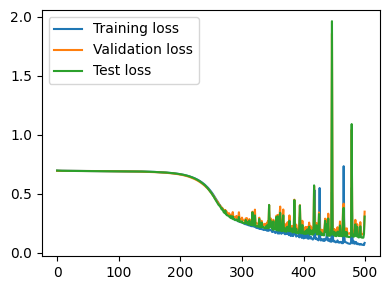

In [86]:
fig, ax = plt.subplots(1,1, figsize=(4,3))
ax.plot(train_losses, label='Training loss')
ax.plot(val_losses, label='Validation loss')
ax.plot(test_losses, label='Test loss')
ax.legend()
plt.tight_layout()
plt.savefig(r'..\..\figures\graph_classification\cosmx_loss_normalized_data.png')

In [87]:
# Pooling of all graphs and save pooled features for downstream analysis
model.eval()
pooled_features = []

cosmx_data = cosmx_data_83 + cosmx_data_84 + cosmx_data_72021 + cosmx_data_72022 + cosmx_data_1741 + cosmx_data_1742
data_loader = DataLoader(cosmx_data, batch_size=128, shuffle=False)

with torch.no_grad():
    for data in data_loader:
        data = data.to(device)
        out = model.encoder(data.x, data.edge_index)
        # out = model.pooling(out, data.edge_index, data.batch)
        out1 = pool.global_mean_pool(out, data.batch)
        out2 = pool.global_max_pool(out, data.batch)
        out = torch.cat([out1, out2], dim=1)

        pooled_features.append(out.cpu().numpy())

c:\Users\zfang38\Anaconda3\envs\torchEnv3\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [88]:
pooled_features[0].shape

(128, 1440)

In [89]:
with open(r'..\..\results\graph_classification\cosmx\pooled_features_normalized_data.pkl', 'wb') as f:
    pickle.dump(pooled_features, f)

In [90]:
with open(r'..\..\results\graph_classification\cosmx\pooled_labels_normalized_data.pkl', 'wb') as f:
    pickle.dump(['SSA+']*(len(cosmx_data_83)+len(cosmx_data_84)) + ['SSA-']*(len(cosmx_data_72021)+len(cosmx_data_72022)+len(cosmx_data_1741)+len(cosmx_data_1742)), f)

In [91]:
# save model
torch.save(model, r'..\..\results\graph_classification\cosmx\model_normalized_data.pth')

In [ ]:
# torch.save(model.state_dict(), r'..\..\results\graph_classification\xenium\model_state_dict_normalized_data.pt')

# explainability

In [29]:
model = torch.load(r'..\..\results\graph_classification\cosmx\model_normalized_data.pth', weights_only=False)

In [30]:
model.to(device)

ClassificationSimplifiedPooling(
  (encoder): GATEncoder(
    (conv1): GATConv(1000, 500, heads=3)
    (convs): ModuleList()
    (conv_out): GATConv(1500, 240, heads=3)
  )
  (classifier): Classifier(
    (fc1): Linear(in_features=1440, out_features=500, bias=True)
    (fcs): ModuleList(
      (0): Linear(in_features=500, out_features=100, bias=True)
    )
    (out): Linear(in_features=100, out_features=2, bias=True)
  )
)

## gnn explainer

### phenomenon

In [15]:
explainer = Explainer(model,
                      algorithm=GNNExplainer(),
                      explanation_type='phenomenon',
                      node_mask_type='attributes',
                      edge_mask_type='object',
                      model_config=dict(mode='multiclass_classification',
                                        task_level='graph',
                                        return_type='raw')
                    )

In [17]:
cosmx_data = cosmx_data_83 + cosmx_data_84 + cosmx_data_72021 + cosmx_data_72022 + cosmx_data_1741 + cosmx_data_1742
data_loader = DataLoader(cosmx_data, batch_size=256, shuffle=False)

explainations = []
for data in data_loader:
    data = data.to(device)
    explanation = explainer(data.x, data.edge_index, batch = data.batch, target=data.label)
    explainations.append(explanation)

c:\Users\zfang38\Anaconda3\envs\torchEnv3\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
c:\Users\zfang38\Anaconda3\envs\torchEnv3\lib\site-packages\torch_geometric\warnings.py:11: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)


In [18]:
edge_masks = []
node_masks = []
for explanation in explainations:
    edge_masks.append(explanation.edge_mask.cpu().numpy())
    node_masks.append(explanation.node_mask.cpu().numpy())
edge_masks = np.concatenate(edge_masks, axis=0)
node_masks = np.concatenate(node_masks, axis=0)

In [20]:
graph_explanations = []
curr_node_idx = 0
curr_edge_idx = 0
for i, data in enumerate(cosmx_data):
    if data.x.shape[0] == 0:
        graph_explanations.append((np.array([]), np.array([])))
        continue
    node_mask = node_masks[curr_node_idx:curr_node_idx+data.x.shape[0]]
    edge_mask = edge_masks[curr_edge_idx:curr_edge_idx+data.edge_index.shape[1]]
    graph_explanations.append((node_mask, edge_mask))
    curr_node_idx += data.x.shape[0]
    curr_edge_idx += data.edge_index.shape[1]

In [21]:
graph_explanations_83 = graph_explanations[:len(cosmx_data_83)]
graph_explanations_84 = graph_explanations[len(cosmx_data_83):len(cosmx_data_83)+len(cosmx_data_84)]
graph_explanations_72021 = graph_explanations[len(cosmx_data_83)+len(cosmx_data_84):len(cosmx_data_83)+len(cosmx_data_84)+len(cosmx_data_72021)]
graph_explanations_72022 = graph_explanations[len(cosmx_data_83)+len(cosmx_data_84)+len(cosmx_data_72021):len(cosmx_data_83)+len(cosmx_data_84)+len(cosmx_data_72021)+len(cosmx_data_72022)]
graph_explanations_1741 = graph_explanations[len(cosmx_data_83)+len(cosmx_data_84)+len(cosmx_data_72021)+len(cosmx_data_72022):len(cosmx_data_83)+len(cosmx_data_84)+len(cosmx_data_72021)+len(cosmx_data_72022)+len(cosmx_data_1741)]
graph_explanations_1742 = graph_explanations[len(cosmx_data_83)+len(cosmx_data_84)+len(cosmx_data_72021)+len(cosmx_data_72022)+len(cosmx_data_1741):]

In [22]:
with open(r'..\..\results\graph_classification\cosmx\explanation_normalized_data_phenomenon_83.pkl', 'wb') as f:
    pickle.dump(graph_explanations_83, f)

with open(r'..\..\results\graph_classification\cosmx\explanation_normalized_data_phenomenon_84.pkl', 'wb') as f:
    pickle.dump(graph_explanations_84, f)

with open(r'..\..\results\graph_classification\cosmx\explanation_normalized_data_phenomenon_72021.pkl', 'wb') as f:
    pickle.dump(graph_explanations_72021, f)

with open(r'..\..\results\graph_classification\cosmx\explanation_normalized_data_phenomenon_72022.pkl', 'wb') as f:
    pickle.dump(graph_explanations_72022, f)

with open(r'..\..\results\graph_classification\cosmx\explanation_normalized_data_phenomenon_1741.pkl', 'wb') as f:
    pickle.dump(graph_explanations_1741, f)

with open(r'..\..\results\graph_classification\cosmx\explanation_normalized_data_phenomenon_1742.pkl', 'wb') as f:
    pickle.dump(graph_explanations_1742, f)

### Model explanation

In [14]:
explainer = Explainer(model,
                        algorithm=GNNExplainer(),
                        explanation_type='model',
                        node_mask_type='attributes',
                        edge_mask_type='object',
                        model_config=dict(mode='multiclass_classification',
                                            task_level='graph',
                                            return_type='raw')
                        )

In [15]:
cosmx_data = cosmx_data_83 + cosmx_data_84 + cosmx_data_72021 + cosmx_data_72022 + cosmx_data_1741 + cosmx_data_1742
data_loader = DataLoader(cosmx_data, batch_size=256, shuffle=False)

explainations = []
for data in data_loader:
    data = data.to(device)
    explanation = explainer(data.x, data.edge_index, batch = data.batch)
    explainations.append(explanation)

c:\Users\zfang38\Anaconda3\envs\torchEnv3\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
c:\Users\zfang38\Anaconda3\envs\torchEnv3\lib\site-packages\torch_geometric\warnings.py:11: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)


In [16]:
edge_masks = []
node_masks = []
for explanation in explainations:
    edge_masks.append(explanation.edge_mask.cpu().numpy())
    node_masks.append(explanation.node_mask.cpu().numpy())
edge_masks = np.concatenate(edge_masks, axis=0)
node_masks = np.concatenate(node_masks, axis=0)

In [17]:
graph_explanations = []
curr_node_idx = 0
curr_edge_idx = 0
for i, data in enumerate(cosmx_data):
    if data.x.shape[0] == 0:
        graph_explanations.append((np.array([]), np.array([])))
        continue
    node_mask = node_masks[curr_node_idx:curr_node_idx+data.x.shape[0]]
    edge_mask = edge_masks[curr_edge_idx:curr_edge_idx+data.edge_index.shape[1]]
    graph_explanations.append((node_mask, edge_mask))
    curr_node_idx += data.x.shape[0]
    curr_edge_idx += data.edge_index.shape[1]

In [18]:
graph_explanations_83 = graph_explanations[:len(cosmx_data_83)]
graph_explanations_84 = graph_explanations[len(cosmx_data_83):len(cosmx_data_83)+len(cosmx_data_84)]
graph_explanations_72021 = graph_explanations[len(cosmx_data_83)+len(cosmx_data_84):len(cosmx_data_83)+len(cosmx_data_84)+len(cosmx_data_72021)]
graph_explanations_72022 = graph_explanations[len(cosmx_data_83)+len(cosmx_data_84)+len(cosmx_data_72021):len(cosmx_data_83)+len(cosmx_data_84)+len(cosmx_data_72021)+len(cosmx_data_72022)]
graph_explanations_1741 = graph_explanations[len(cosmx_data_83)+len(cosmx_data_84)+len(cosmx_data_72021)+len(cosmx_data_72022):len(cosmx_data_83)+len(cosmx_data_84)+len(cosmx_data_72021)+len(cosmx_data_72022)+len(cosmx_data_1741)]
graph_explanations_1742 = graph_explanations[len(cosmx_data_83)+len(cosmx_data_84)+len(cosmx_data_72021)+len(cosmx_data_72022)+len(cosmx_data_1741):]

In [19]:
with open(r'..\..\results\graph_classification\cosmx\explanation_normalized_data_model_83.pkl', 'wb') as f:
    pickle.dump(graph_explanations_83, f)

with open(r'..\..\results\graph_classification\cosmx\explanation_normalized_data_model_84.pkl', 'wb') as f:
    pickle.dump(graph_explanations_84, f)

with open(r'..\..\results\graph_classification\cosmx\explanation_normalized_data_model_72021.pkl', 'wb') as f:
    pickle.dump(graph_explanations_72021, f)

with open(r'..\..\results\graph_classification\cosmx\explanation_normalized_data_model_72022.pkl', 'wb') as f:
    pickle.dump(graph_explanations_72022, f)

with open(r'..\..\results\graph_classification\cosmx\explanation_normalized_data_model_1741.pkl', 'wb') as f:
    pickle.dump(graph_explanations_1741, f)

with open(r'..\..\results\graph_classification\cosmx\explanation_normalized_data_model_1742.pkl', 'wb') as f:
    pickle.dump(graph_explanations_1742, f)

## Attention Explainer

In [31]:
explainer = Explainer(model,
                        algorithm=AttentionExplainer(),
                        explanation_type='model',
                        node_mask_type=None,
                        edge_mask_type='object',
                        model_config=dict(mode='multiclass_classification',
                                            task_level='graph',
                                            return_type='raw')
                        )

In [60]:
cosmx_data = cosmx_data_83 + cosmx_data_84 + cosmx_data_72021 + cosmx_data_72022 + cosmx_data_1741 + cosmx_data_1742
data_loader = DataLoader(cosmx_data, batch_size=256, shuffle=False)

edge_explainations = []
for data in data_loader:
    data = data.to(device)
    explanation = explainer(data.x, data.edge_index, batch = data.batch)
    edge_explainations.append(explanation)

In [64]:
edge_masks = []
for explanation in edge_explainations:
    edge_masks.append(explanation.edge_mask.cpu().numpy())
edge_masks = np.concatenate(edge_masks, axis=0)

In [66]:
graph_explanations = []
curr_edge_idx = 0
for i, data in enumerate(cosmx_data):
    if data.x.shape[0] == 0:
        graph_explanations.append(np.array([]))
        continue
    edge_mask = edge_masks[curr_edge_idx:curr_edge_idx+data.edge_index.shape[1]]
    graph_explanations.append(edge_mask)
    curr_edge_idx += data.edge_index.shape[1]

In [67]:
len(graph_explanations)

7340

In [68]:
graph_explanations_83 = graph_explanations[:len(cosmx_data_83)]
graph_explanations_84 = graph_explanations[len(cosmx_data_83):len(cosmx_data_83)+len(cosmx_data_84)]
graph_explanations_72021 = graph_explanations[len(cosmx_data_83)+len(cosmx_data_84):len(cosmx_data_83)+len(cosmx_data_84)+len(cosmx_data_72021)]
graph_explanations_72022 = graph_explanations[len(cosmx_data_83)+len(cosmx_data_84)+len(cosmx_data_72021):len(cosmx_data_83)+len(cosmx_data_84)+len(cosmx_data_72021)+len(cosmx_data_72022)]
graph_explanations_1741 = graph_explanations[len(cosmx_data_83)+len(cosmx_data_84)+len(cosmx_data_72021)+len(cosmx_data_72022):len(cosmx_data_83)+len(cosmx_data_84)+len(cosmx_data_72021)+len(cosmx_data_72022)+len(cosmx_data_1741)]
graph_explanations_1742 = graph_explanations[len(cosmx_data_83)+len(cosmx_data_84)+len(cosmx_data_72021)+len(cosmx_data_72022)+len(cosmx_data_1741):]

In [69]:
with open(r'..\..\results\graph_classification\cosmx\explanation_normalized_data_gat_83.pkl', 'wb') as f:
    pickle.dump(graph_explanations_83, f)

with open(r'..\..\results\graph_classification\cosmx\explanation_normalized_data_gat_84.pkl', 'wb') as f:
    pickle.dump(graph_explanations_84, f)

with open(r'..\..\results\graph_classification\cosmx\explanation_normalized_data_gat_72021.pkl', 'wb') as f:
    pickle.dump(graph_explanations_72021, f)

with open(r'..\..\results\graph_classification\cosmx\explanation_normalized_data_gat_72022.pkl', 'wb') as f:
    pickle.dump(graph_explanations_72022, f)

with open(r'..\..\results\graph_classification\cosmx\explanation_normalized_data_gat_1741.pkl', 'wb') as f:
    pickle.dump(graph_explanations_1741, f)

with open(r'..\..\results\graph_classification\cosmx\explanation_normalized_data_gat_1742.pkl', 'wb') as f:
    pickle.dump(graph_explanations_1742, f)

# classification using normalized common genes

## load data

### xenium 83a

In [6]:
graphs = pd.read_pickle(r'..\..\results\graph_classification_v4\xenium\sub_graphs_83a.pkl')
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r'..\..\results\graph_classification_v4\dann\expression\xenium_83a.csv', index_col=0)
# exp_df.drop(columns=['sample'], inplace=True)

In [10]:
data_83a = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 1) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:   26.7s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:   26.9s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:   26.9s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:   26.9s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:   27.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:   27.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:   27.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:   27.0s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:   27.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:   27.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:   27.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:   27.1s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:   27.2s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:   27.2s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

In [11]:
with open(r'..\..\results\graph_classification_v4\dann\xenium_torch_data\sub_graphs_83a.pkl', 'wb') as f:
    pickle.dump(data_83a, f)

### xenium 83b

In [12]:
graphs = pd.read_pickle(r'..\..\results\graph_classification_v4\xenium\sub_graphs_83b.pkl')
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r'..\..\results\graph_classification_v4\dann\expression\xenium_83b.csv', index_col=0)

In [13]:
data_83b = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 1) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.10016083717346191s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]

In [14]:
with open(r'..\..\results\graph_classification_v4\dann\xenium_torch_data\sub_graphs_83b.pkl', 'wb') as f:
    pickle.dump(data_83b, f)

### xenium 84a

In [15]:
graphs = pd.read_pickle(r'..\..\results\graph_classification_v4\xenium\sub_graphs_84a.pkl')
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r'..\..\results\graph_classification_v4\dann\expression\xenium_84a.csv', index_col=0)

In [16]:
data_84a = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 1) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.09756708145141602s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]

In [17]:
with open(r'..\..\results\graph_classification_v4\dann\xenium_torch_data\sub_graphs_84a.pkl', 'wb') as f:
    pickle.dump(data_84a, f)

### xenium 84b

In [18]:
graphs = pd.read_pickle(r'..\..\results\graph_classification_v4\xenium\sub_graphs_84b.pkl')
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r'..\..\results\graph_classification_v4\dann\expression\xenium_84b.csv', index_col=0)

In [19]:
data_84b = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 1) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.10651302337646484s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]

In [20]:
with open(r'..\..\results\graph_classification_v4\dann\xenium_torch_data\sub_graphs_84b.pkl', 'wb') as f:
    pickle.dump(data_84b, f)

### xenium 174c

In [21]:
graphs = pd.read_pickle(r'..\..\results\graph_classification_v4\xenium\sub_graphs_174c.pkl')
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r'..\..\results\graph_classification_v4\dann\expression\xenium_174c.csv', index_col=0)

In [22]:
data_174c = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 0) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.041608572006225586s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)

In [23]:
with open(r'..\..\results\graph_classification_v4\dann\xenium_torch_data\sub_graphs_174c.pkl', 'wb') as f:
    pickle.dump(data_174c, f)

### xenium 174d

In [24]:
graphs = pd.read_pickle(r'..\..\results\graph_classification_v4\xenium\sub_graphs_174d.pkl')
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r'..\..\results\graph_classification_v4\dann\expression\xenium_174d.csv', index_col=0)

In [25]:
data_174d = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 0) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.04432082176208496s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]

In [26]:
with open(r'..\..\results\graph_classification_v4\dann\xenium_torch_data\sub_graphs_174d.pkl', 'wb') as f:
    pickle.dump(data_174d, f)

### xenium 7202c

In [27]:
graphs = pd.read_pickle(r'..\..\results\graph_classification_v4\xenium\sub_graphs_7202c.pkl')
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r'..\..\results\graph_classification_v4\dann\expression\xenium_7202c.csv', index_col=0)

In [28]:
data_7202c = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 0) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.051489830017089844s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)

In [29]:
with open(r'..\..\results\graph_classification_v4\dann\xenium_torch_data\sub_graphs_7202c.pkl', 'wb') as f:
    pickle.dump(data_7202c, f)

### xenium 7202d

In [30]:
graphs = pd.read_pickle(r'..\..\results\graph_classification_v4\xenium\sub_graphs_7202d.pkl')
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r'..\..\results\graph_classification_v4\dann\expression\xenium_7202d.csv', index_col=0)

In [31]:
data_7202d = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 0) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.05064821243286133s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]

In [32]:
with open(r'..\..\results\graph_classification_v4\dann\xenium_torch_data\sub_graphs_7202d.pkl', 'wb') as f:
    pickle.dump(data_7202d, f)

### cosmx 83

In [92]:
graphs = pd.read_pickle(r'..\..\results\graph_classification_v4\cosmx\sub_graphs_83.pkl')
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r'..\..\results\graph_classification_v4\dann\expression\cosmx_83.csv', index_col=0)

In [93]:
cosmx_data_83 = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 1) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

In [94]:
with open(r'..\..\results\graph_classification_v4\dann\cosmx_torch_data\sub_graphs_cosmx_83.pkl', 'wb') as f:
    pickle.dump(cosmx_data_83, f)

### cosmx 84

In [95]:
graphs = pd.read_pickle(r'..\..\results\graph_classification_v4\cosmx\sub_graphs_84.pkl')
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r'..\..\results\graph_classification_v4\dann\expression\cosmx_84.csv', index_col=0)

In [96]:
exp_df.index = exp_df.index.map(lambda x: f"c_{int(x.split('_')[1])-1}_{x.split('_')[2]}_{x.split('_')[3]}")

In [97]:
cosmx_data_84 = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 1) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.17475461959838867s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]

In [98]:
with open(r'..\..\results\graph_classification_v4\dann\cosmx_torch_data\sub_graphs_cosmx_84.pkl', 'wb') as f:
    pickle.dump(cosmx_data_84, f)

### cosmx 174-1

In [99]:
graphs = pd.read_pickle(r'..\..\results\graph_classification_v4\cosmx\sub_graphs_1741.pkl')
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r'..\..\results\graph_classification_v4\dann\expression\cosmx_1741.csv', index_col=0)

In [100]:
cosmx_data_1741 = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 0) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.08500003814697266s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 out of  34 | elapsed:    0.0s remaining:    1.6s
[Parallel(n_jobs=-3)]: Done   3 out of  34 | elapsed:    0.0s remaining:    1.2s
[Parallel(n_jobs=-3)]: Done   4 out of  34 | elapsed:    0.0s remaining:    0.9s
[Parallel(n_jobs=-3)]: Done   5 out of  34 | elapsed:    0.1s remaining:    0.8s
[Parallel(n_jobs=-3)]: Done   6 out of  34 | elapsed:    0.1s remaining:    0.6s
[Parallel(n_jobs=-3)]: Done   7 out of  34 | elapsed:    0.1s remaining:    0.5s
[Parallel(n_jobs=-3)]: Done   8 out of  34 | elapsed:    0.1s remaining:    0.5s
[Parallel(n_jobs=-3)]: Done   9 out of  34 | elapsed:    0.1s remaining:    0.4s
[Parallel(n_jobs=-3)]: Done  10 out of  34 | elapsed:    0.1s remaining:    0.4s
[Parallel(n_jobs=-3)]: Done  11 out 

In [101]:
with open(r'..\..\results\graph_classification_v4\dann\cosmx_torch_data\sub_graphs_cosmx_1741.pkl', 'wb') as f:
    pickle.dump(cosmx_data_1741, f)

### cosmx 174-2

In [102]:
graphs = pd.read_pickle(r'..\..\results\graph_classification_v4\cosmx\sub_graphs_1742.pkl')
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r'..\..\results\graph_classification_v4\dann\expression\cosmx_1742.csv', index_col=0)

In [103]:
cosmx_data_1742 = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 0) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.09099960327148438s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 out of  45 | elapsed:    0.0s remaining:    2.3s
[Parallel(n_jobs=-3)]: Done   3 out of  45 | elapsed:    0.0s remaining:    1.7s
[Parallel(n_jobs=-3)]: Done   4 out of  45 | elapsed:    0.0s remaining:    1.3s
[Parallel(n_jobs=-3)]: Done   5 out of  45 | elapsed:    0.0s remaining:    1.1s
[Parallel(n_jobs=-3)]: Done   6 out of  45 | elapsed:    0.0s remaining:    0.9s
[Parallel(n_jobs=-3)]: Done   7 out of  45 | elapsed:    0.1s remaining:    0.7s
[Parallel(n_jobs=-3)]: Done   8 out of  45 | elapsed:    0.1s remaining:    0.6s
[Parallel(n_jobs=-3)]: Done   9 out of  45 | elapsed:    0.1s remaining:    0.6s
[Parallel(n_jobs=-3)]: Done  10 out of  45 | elapsed:    0.1s remaining:    0.5s
[Parallel(n_jobs=-3)]: Done  11 out 

In [104]:
with open(r'..\..\results\graph_classification_v4\dann\cosmx_torch_data\sub_graphs_cosmx_1742.pkl', 'wb') as f:
    pickle.dump(cosmx_data_1742, f)

### cosmx 7202-1

In [105]:
graphs = pd.read_pickle(r'..\..\results\graph_classification_v4\cosmx\sub_graphs_72021.pkl')
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r'..\..\results\graph_classification_v4\dann\expression\cosmx_72021.csv', index_col=0)

In [106]:
cosmx_data_72021 = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 0) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.09903693199157715s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]

In [107]:
with open(r'..\..\results\graph_classification_v4\dann\cosmx_torch_data\sub_graphs_cosmx_72021.pkl', 'wb') as f:
    pickle.dump(cosmx_data_72021, f)

### cosmx 7202-2

In [108]:
graphs = pd.read_pickle(r'..\..\results\graph_classification_v4\cosmx\sub_graphs_72022.pkl')
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r'..\..\results\graph_classification_v4\dann\expression\cosmx_72022.csv', index_col=0)

In [109]:
cosmx_data_72022 = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 0) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.10700845718383789s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 out of  83 | elapsed:    0.0s remaining:    4.9s
[Parallel(n_jobs=-3)]: Done   3 out of  83 | elapsed:    0.0s remaining:    3.6s
[Parallel(n_jobs=-3)]: Done   4 out of  83 | elapsed:    0.1s remaining:    2.9s
[Parallel(n_jobs=-3)]: Done   5 out of  83 | elapsed:    0.1s remaining:    2.5s
[Parallel(n_jobs=-3)]: Done   6 out of  83 | elapsed:    0.1s remaining:    2.2s
[Parallel(n_jobs=-3)]: Done   7 out of  83 | elapsed:    0.1s remaining:    2.0s
[Parallel(n_jobs=-3)]: Done   8 out of  83 | elapsed:    0.1s remaining:    1.8s
[Parallel(n_jobs=-3)]: Done   9 out of  83 | elapsed:    0.1s remaining:    1.6s
[Parallel(n_jobs=-3)]: Done  10 out of  83 | elapsed:    0.1s remaining:    1.4s
[Parallel(n_jobs=-3)]: Done  11 out 

In [110]:
with open(r'..\..\results\graph_classification_v4\dann\cosmx_torch_data\sub_graphs_cosmx_72022.pkl', 'wb') as f:
    pickle.dump(cosmx_data_72022, f)

In [17]:
data_83a = pd.read_pickle(r'..\..\results\graph_classification\common_genes\dataObjects\sub_graphs_83a.pkl')
data_83b = pd.read_pickle(r'..\..\results\graph_classification\common_genes\dataObjects\sub_graphs_83b.pkl')
data_84a = pd.read_pickle(r'..\..\results\graph_classification\common_genes\dataObjects\sub_graphs_84a.pkl')
data_84b = pd.read_pickle(r'..\..\results\graph_classification\common_genes\dataObjects\sub_graphs_84b.pkl')
data_174c = pd.read_pickle(r'..\..\results\graph_classification\common_genes\dataObjects\sub_graphs_174c.pkl')
data_174d = pd.read_pickle(r'..\..\results\graph_classification\common_genes\dataObjects\sub_graphs_174d.pkl')
data_7202c = pd.read_pickle(r'..\..\results\graph_classification\common_genes\dataObjects\sub_graphs_7202c.pkl')
data_7202d = pd.read_pickle(r'..\..\results\graph_classification\common_genes\dataObjects\sub_graphs_7202d.pkl')

cosmx_data_83 = pd.read_pickle(r'..\..\results\graph_classification\common_genes\dataObjects\sub_graphs_cosmx_83.pkl')
cosmx_data_84 = pd.read_pickle(r'..\..\results\graph_classification\common_genes\dataObjects\sub_graphs_cosmx_84.pkl')
cosmx_data_1741 = pd.read_pickle(r'..\..\results\graph_classification\common_genes\dataObjects\sub_graphs_cosmx_1741.pkl')
cosmx_data_1742 = pd.read_pickle(r'..\..\results\graph_classification\common_genes\dataObjects\sub_graphs_cosmx_1742.pkl')
cosmx_data_72021 = pd.read_pickle(r'..\..\results\graph_classification\common_genes\dataObjects\sub_graphs_cosmx_72021.pkl')
cosmx_data_72022 = pd.read_pickle(r'..\..\results\graph_classification\common_genes\dataObjects\sub_graphs_cosmx_72022.pkl')

In [18]:
# remove any data object with .x shape 0
data_83a = [data for data in data_83a if data.x.shape[0] != 0]
data_83b = [data for data in data_83b if data.x.shape[0] != 0]
data_84a = [data for data in data_84a if data.x.shape[0] != 0]
data_84b = [data for data in data_84b if data.x.shape[0] != 0]
data_174c = [data for data in data_174c if data.x.shape[0] != 0]
data_174d = [data for data in data_174d if data.x.shape[0] != 0]
data_7202c = [data for data in data_7202c if data.x.shape[0] != 0]
data_7202d = [data for data in data_7202d if data.x.shape[0] != 0]

cosmx_data_83 = [data for data in cosmx_data_83 if data.x.shape[0] != 0]
cosmx_data_84 = [data for data in cosmx_data_84 if data.x.shape[0] != 0]
cosmx_data_1741 = [data for data in cosmx_data_1741 if data.x.shape[0] != 0]
cosmx_data_1742 = [data for data in cosmx_data_1742 if data.x.shape[0] != 0]
cosmx_data_72021 = [data for data in cosmx_data_72021 if data.x.shape[0] != 0]
cosmx_data_72022 = [data for data in cosmx_data_72022 if data.x.shape[0] != 0]

## splitting

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
data = data_83a + data_83b + data_84a + data_84b + data_174c + data_174d + data_7202c + data_7202d + cosmx_data_83 + cosmx_data_84 + cosmx_data_72021 + cosmx_data_72022 + cosmx_data_1741 + cosmx_data_1742
labels = ['SSA+']*(len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)) + ['SSA-']*(len(data_174c)+len(data_174d)+len(data_7202c)+len(data_7202d))+['SSA+']*(len(cosmx_data_83)+len(cosmx_data_84))+['SSA-']*(len(cosmx_data_72021)+len(cosmx_data_72022)+len(cosmx_data_1741)+len(cosmx_data_1742))

In [21]:
assert(len(data) == len(labels))

In [22]:
train_data, test_data, train_label, test_label = train_test_split(data, labels, test_size=0.2, random_state=42)
train_data, val_data, train_label, val_label = train_test_split(train_data, train_label, test_size=0.25, random_state=42)

In [23]:
len(train_data)

35274

In [24]:
np.sum(np.array(train_label) == 'SSA+')

np.int64(25483)

In [25]:
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
val_loader = DataLoader(val_data, batch_size=256, shuffle=False)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

c:\Users\zfang38\Anaconda3\envs\torchEnv3\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


## training

In [ ]:
from torch.nn import CrossEntropyLoss
from torch.optim import Adam, SGD

In [96]:
# model = Classification([480, [360], 240, [3]], [720, 100, 50], [50, [20], 2])
model = ClassificationSimplifiedPooling([260, [200], 120, [3]], [720, [200, 100], 2])

In [97]:
model.to(device)

ClassificationSimplifiedPooling(
  (encoder): GATEncoder(
    (conv1): GATConv(260, 200, heads=3)
    (convs): ModuleList()
    (conv_out): GATConv(600, 120, heads=3)
  )
  (classifier): Classifier(
    (fc1): Linear(in_features=720, out_features=200, bias=True)
    (fcs): ModuleList(
      (0): Linear(in_features=200, out_features=100, bias=True)
    )
    (out): Linear(in_features=100, out_features=2, bias=True)
  )
)

In [98]:
data[0].to(device)
with torch.no_grad():
    print(model(data[0].x, data[0].edge_index, data[0].batch))

tensor([[-0.0887, -0.0703]], device='cuda:0')


In [99]:
data[0].to('cpu')

Data(x=[9, 260], edge_index=[2, 18], label=[1])

In [3]:
train_data

NameError: name 'train_data' is not defined

In [100]:
optimizer = SGD(model.parameters(), lr=0.01)
criterion = CrossEntropyLoss(torch.tensor([3332/(4404-3332), 1]).to(device))

In [101]:
def train(loader):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        if data.label.shape[0] != out.shape[0]:
            min_size = min(out.shape[0], data.label.shape[0])
            out = out[:min_size]
            data.label = data.label[:min_size]
        loss = criterion(out, data.label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

def val(loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)

            # Ensure label shape matches output
            if data.label.shape[0] != out.shape[0]:
                min_size = min(out.shape[0], data.label.shape[0])
                out = out[:min_size]
                data.label = data.label[:min_size]

            loss = criterion(out, data.label)
            total_loss += loss.item() * data.num_graphs

    return total_loss / len(loader.dataset)


In [102]:
train_losses = []
val_losses = []
test_losses = []

In [103]:
epochs = 300

In [104]:
for epoch in range(epochs):
    train_loss = train(train_loader)
    val_loss = val(val_loader)
    test_loss = val(test_loader)
    print(f'Epoch: {epoch}, Train Loss: {train_loss}, Val Loss: {val_loss}, Test Loss: {test_loss}')
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    test_losses.append(test_loss)

Epoch: 0, Train Loss: 0.6911490321051218, Val Loss: 0.690218082231047, Test Loss: 0.6897094851348002
Epoch: 1, Train Loss: 0.6886175100161401, Val Loss: 0.6892228205505329, Test Loss: 0.6884825370875036
Epoch: 2, Train Loss: 0.6875036314561563, Val Loss: 0.6884691696382741, Test Loss: 0.6876647944940274
Epoch: 3, Train Loss: 0.6865987526577617, Val Loss: 0.6876396779544419, Test Loss: 0.6868062953110312
Epoch: 4, Train Loss: 0.6856335314715092, Val Loss: 0.6865800428520277, Test Loss: 0.6857644130449998
Epoch: 5, Train Loss: 0.6844396292369112, Val Loss: 0.6851197251820974, Test Loss: 0.684386996858723
Epoch: 6, Train Loss: 0.6828259130166882, Val Loss: 0.6832399440067198, Test Loss: 0.682577392209
Epoch: 7, Train Loss: 0.6806805811920843, Val Loss: 0.6807414243306041, Test Loss: 0.6801512196449666
Epoch: 8, Train Loss: 0.6777635868521527, Val Loss: 0.6770949309872697, Test Loss: 0.6766900349218924
Epoch: 9, Train Loss: 0.6735125888013755, Val Loss: 0.6719335295306843, Test Loss: 0.671

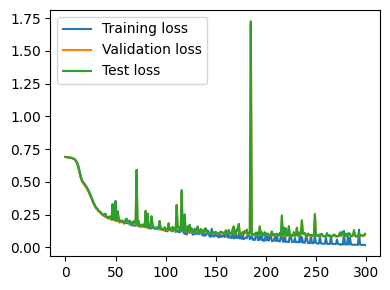

In [105]:
fig, ax = plt.subplots(1,1, figsize=(4,3))
ax.plot(train_losses, label='Training loss')
ax.plot(val_losses, label='Validation loss')
ax.plot(test_losses, label='Test loss')
ax.legend()
plt.tight_layout()
plt.savefig(r'..\..\figures\graph_classification\combined_loss_normalized_data.png')

## evaluation

In [21]:
model = torch.load(r'..\..\results\graph_classification\common_genes\model_normalized_data.pth', weights_only=False)

In [22]:
model.to(device)

ClassificationSimplifiedPooling(
  (encoder): GATEncoder(
    (conv1): GATConv(260, 200, heads=3)
    (convs): ModuleList()
    (conv_out): GATConv(600, 120, heads=3)
  )
  (classifier): Classifier(
    (fc1): Linear(in_features=720, out_features=200, bias=True)
    (fcs): ModuleList(
      (0): Linear(in_features=200, out_features=100, bias=True)
    )
    (out): Linear(in_features=100, out_features=2, bias=True)
  )
)

In [23]:
# Pooling of all graphs and save pooled features for downstream analysis
model.eval()
pooled_features = []

data = data_83a + data_83b + data_84a + data_84b + data_174c + data_174d + data_7202c + data_7202d + cosmx_data_83 + cosmx_data_84 + cosmx_data_72021 + cosmx_data_72022 + cosmx_data_1741 + cosmx_data_1742
data_loader = DataLoader(data, batch_size=256, shuffle=False)

with torch.no_grad():
    for data in data_loader:
        data = data.to(device)
        out = model.encoder(data.x, data.edge_index)
        # out = model.pooling(out, data.edge_index, data.batch)
        out1 = pool.global_mean_pool(out, data.batch)
        out2 = pool.global_max_pool(out, data.batch)
        out = torch.cat([out1, out2], dim=1)

        pooled_features.append(out.cpu().numpy())

c:\Users\zfang38\Anaconda3\envs\torchEnv3\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [41]:
slices = ['Xenium_83a']*len(data_83a) + ['Xenium_83b']*len(data_83b)+\
         ['Xenium_84a']*len(data_84a) + ['Xenium_84b']*len(data_84b)+\
         ['Xenium_174c']*len(data_174c) + ['Xenium_174d']*len(data_174d)+\
         ['Xenium_7202c']*len(data_7202c) + ['Xenium_7202d']*len(data_7202d)+\
         ['Cosmx_83']*len(cosmx_data_83) + ['Cosmx_84']*len(cosmx_data_84)+\
         ['Cosmx_72021']*len(cosmx_data_72021) + ['Cosmx_72022']*len(cosmx_data_72022)+\
         ['Cosmx_1741']*len(cosmx_data_1741) + ['Cosmx_1742']*len(cosmx_data_1742)

In [42]:
with open(r'..\..\results\graph_classification\common_genes\tissue_id.pkl', 'wb') as f:
    pickle.dump(slices, f)

In [34]:
with open(r'..\..\results\graph_classification\common_genes\pooled_features_normalized_data.pkl', 'wb') as f:
    pickle.dump(pooled_features, f)

In [35]:
labels = ['SSA+']*(len(data_83a)+len(data_83b)+len(data_84a)+len(data_84b)) +\
         ['SSA-']*(len(data_174c)+len(data_174d)+len(data_7202c)+len(data_7202d)) +\
         ['SSA+']*(len(cosmx_data_83)+len(cosmx_data_84)) +\
         ['SSA-']*(len(cosmx_data_72021)+len(cosmx_data_72022)+len(cosmx_data_1741)+len(cosmx_data_1742))

In [36]:
with open(r'..\..\results\graph_classification\common_genes\pooled_labels_normalized_data.pkl', 'wb') as f:
    pickle.dump(labels, f)

In [ ]:
# save model
# torch.save(model, r'..\..\results\graph_classification\common_genes\model_normalized_data.pth')

In [ ]:
# torch.save(model.state_dict(), r'..\..\results\graph_classification\xenium\model_state_dict_normalized_data.pt')

## classification metrics

In [73]:
from sklearn.metrics import confusion_matrix

In [78]:
model = torch.load(r'..\..\results\graph_classification_v4\xenium\model_normalized_data.pth', weights_only=False)

In [79]:
model.to(device)

ClassificationSimplifiedPooling(
  (encoder): GATEncoder(
    (conv1): GATConv(480, 360, heads=3)
    (convs): ModuleList()
    (conv_out): GATConv(1080, 240, heads=3)
  )
  (classifier): Classifier(
    (fc1): Linear(in_features=1440, out_features=500, bias=True)
    (fcs): ModuleList(
      (0): Linear(in_features=500, out_features=100, bias=True)
    )
    (out): Linear(in_features=100, out_features=2, bias=True)
  )
)

In [80]:
# Ensure the model is in evaluation mode
model.eval()

# Initialize lists to store true labels and predictions
true_labels = []
pred_labels = []

# Iterate over the test_loader
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        _, pred = torch.max(out, dim=1)
        true_labels.extend(data.label.cpu().numpy())
        pred_labels.extend(pred.cpu().numpy())

# Compute the confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

In [81]:
cm

array([[2086,   78],
       [  61, 4483]])

In [82]:
(2086+4483) / np.sum(cm)

np.float64(0.97927847346452)

In [38]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [36]:
pred_probs = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        pred_probs.extend(out.cpu().numpy()[:,1])
auc = roc_auc_score(true_labels, pred_probs)

In [37]:
auc

np.float64(0.9956937402753313)

In [39]:
roc_curve = roc_curve(true_labels, pred_probs)

In [50]:
from matplotlib import rc_context

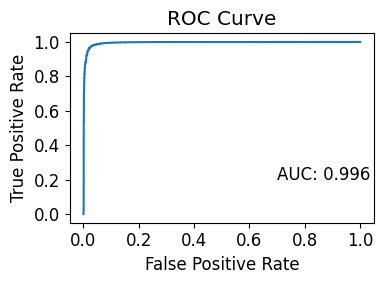

In [55]:
with rc_context({'font.size':12}):
    fig, ax = plt.subplots(1,1,figsize=(4,3))
    ax.plot(roc_curve[0], roc_curve[1])
    ax.text(0.7, 0.2, f'AUC: {auc:.3f}', fontsize=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve')
    plt.tight_layout()
    plt.savefig(r'..\..\figures\graph_classification\roc_curve_normalized_data.png')

## Explanability analysis

In [120]:
model = torch.load(r'..\..\results\graph_classification\common_genes\model_normalized_data.pth', weights_only=False)

In [122]:
model.to(device)

ClassificationSimplifiedPooling(
  (encoder): GATEncoder(
    (conv1): GATConv(260, 200, heads=3)
    (convs): ModuleList()
    (conv_out): GATConv(600, 120, heads=3)
  )
  (classifier): Classifier(
    (fc1): Linear(in_features=720, out_features=200, bias=True)
    (fcs): ModuleList(
      (0): Linear(in_features=200, out_features=100, bias=True)
    )
    (out): Linear(in_features=100, out_features=2, bias=True)
  )
)

### gnnexplainer

In [123]:
explainer = Explainer(model,
                        algorithm=GNNExplainer(),
                        explanation_type='model',
                        node_mask_type='attributes',
                        edge_mask_type='object',
                        model_config=dict(mode='multiclass_classification',
                                            task_level='graph',
                                            return_type='raw')
                        )

In [124]:
data_og = data_83a + data_83b + data_84a + data_84b + data_174c + data_174d + data_7202c + data_7202d + cosmx_data_83 + cosmx_data_84 + cosmx_data_72021 + cosmx_data_72022 + cosmx_data_1741 + cosmx_data_1742
data_loader = DataLoader(data_og, batch_size=256, shuffle=False)

explainations = []
for data in tqdm(data_loader):
    data = data.to(device)
    explanation = explainer(data.x, data.edge_index, batch = data.batch)
    explainations.append(explanation)

c:\Users\zfang38\Anaconda3\envs\torchEnv3\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
  0%|          | 0/230 [00:00<?, ?it/s]

c:\Users\zfang38\Anaconda3\envs\torchEnv3\lib\site-packages\torch_geometric\warnings.py:11: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)
100%|██████████| 230/230 [10:22<00:00,  2.71s/it]


In [125]:
edge_masks = []
node_masks = []
for explanation in explainations:
    edge_masks.append(explanation.edge_mask.cpu().numpy())
    node_masks.append(explanation.node_mask.cpu().numpy())
edge_masks = np.concatenate(edge_masks, axis=0)
node_masks = np.concatenate(node_masks, axis=0)

In [126]:
graph_explanations = []
curr_node_idx = 0
curr_edge_idx = 0
for i, data in enumerate(data_og):
    if data.x.shape[0] == 0:
        graph_explanations.append((np.array([]), np.array([])))
        continue
    node_mask = node_masks[curr_node_idx:curr_node_idx+data.x.shape[0]]
    edge_mask = edge_masks[curr_edge_idx:curr_edge_idx+data.edge_index.shape[1]]
    graph_explanations.append((node_mask, edge_mask))
    curr_node_idx += data.x.shape[0]
    curr_edge_idx += data.edge_index.shape[1]

In [127]:
curr_idx = 0
xenium_83a_explanation = graph_explanations[curr_idx:curr_idx+len(data_83a)]
curr_idx += len(data_83a)

xenium_83b_explanation = graph_explanations[curr_idx:curr_idx+len(data_83b)]
curr_idx += len(data_83b)

xenium_84a_explanation = graph_explanations[curr_idx:curr_idx+len(data_84a)]
curr_idx += len(data_84a)

xenium_84b_explanation = graph_explanations[curr_idx:curr_idx+len(data_84b)]
curr_idx += len(data_84b)

xenium_174c_explanation = graph_explanations[curr_idx:curr_idx+len(data_174c)]
curr_idx += len(data_174c)

xenium_174d_explanation = graph_explanations[curr_idx:curr_idx+len(data_174d)]
curr_idx += len(data_174d)

xenium_7202c_explanation = graph_explanations[curr_idx:curr_idx+len(data_7202c)]
curr_idx += len(data_7202c)

xenium_7202d_explanation = graph_explanations[curr_idx:curr_idx+len(data_7202d)]
curr_idx += len(data_7202d)

cosmx_83_explanation = graph_explanations[curr_idx:curr_idx+len(cosmx_data_83)]
curr_idx += len(cosmx_data_83)

cosmx_84_explanation = graph_explanations[curr_idx:curr_idx+len(cosmx_data_84)]
curr_idx += len(cosmx_data_84)

cosmx_72021_explanation = graph_explanations[curr_idx:curr_idx+len(cosmx_data_72021)]
curr_idx += len(cosmx_data_72021)

cosmx_72022_explanation = graph_explanations[curr_idx:curr_idx+len(cosmx_data_72022)]
curr_idx += len(cosmx_data_72022)

cosmx_1741_explanation = graph_explanations[curr_idx:curr_idx+len(cosmx_data_1741)]
curr_idx += len(cosmx_data_1741)

cosmx_1742_explanation = graph_explanations[curr_idx:curr_idx+len(cosmx_data_1742)]

In [132]:
with open(r'..\..\results\graph_classification\common_genes\explanation_normalized_data_model_83a.pkl', 'wb') as f:
    pickle.dump(xenium_83a_explanation, f)

with open(r'..\..\results\graph_classification\common_genes\explanation_normalized_data_model_83b.pkl', 'wb') as f:
    pickle.dump(xenium_83b_explanation, f)

with open(r'..\..\results\graph_classification\common_genes\explanation_normalized_data_model_84a.pkl', 'wb') as f:
    pickle.dump(xenium_84a_explanation, f)

with open(r'..\..\results\graph_classification\common_genes\explanation_normalized_data_model_84b.pkl', 'wb') as f:
    pickle.dump(xenium_84b_explanation, f)

with open(r'..\..\results\graph_classification\common_genes\explanation_normalized_data_model_174c.pkl', 'wb') as f:
    pickle.dump(xenium_174c_explanation, f)

with open(r'..\..\results\graph_classification\common_genes\explanation_normalized_data_model_174d.pkl', 'wb') as f:
    pickle.dump(xenium_174d_explanation, f)

with open(r'..\..\results\graph_classification\common_genes\explanation_normalized_data_model_7202c.pkl', 'wb') as f:
    pickle.dump(xenium_7202c_explanation, f)

with open(r'..\..\results\graph_classification\common_genes\explanation_normalized_data_model_7202d.pkl', 'wb') as f:
    pickle.dump(xenium_7202d_explanation, f)

with open(r'..\..\results\graph_classification\common_genes\explanation_normalized_data_model_cosmx_83.pkl', 'wb') as f:
    pickle.dump(cosmx_83_explanation, f)

with open(r'..\..\results\graph_classification\common_genes\explanation_normalized_data_model_cosmx_84.pkl', 'wb') as f:
    pickle.dump(cosmx_84_explanation, f)

with open(r'..\..\results\graph_classification\common_genes\explanation_normalized_data_model_cosmx_72021.pkl', 'wb') as f:
    pickle.dump(cosmx_72021_explanation, f)

with open(r'..\..\results\graph_classification\common_genes\explanation_normalized_data_model_cosmx_72022.pkl', 'wb') as f:
    pickle.dump(cosmx_72022_explanation, f)

with open(r'..\..\results\graph_classification\common_genes\explanation_normalized_data_model_cosmx_1741.pkl', 'wb') as f:
    pickle.dump(cosmx_1741_explanation, f)

with open(r'..\..\results\graph_classification\common_genes\explanation_normalized_data_model_cosmx_1742.pkl', 'wb') as f:
    pickle.dump(cosmx_1742_explanation, f)